# Fáza 3 - Strojové učenie: 20 bodov
Pri dátovej analýze nemusí byť naším cieľom získať len znalosti obsiahnuté v aktuálnych dátach, ale aj natrénovať model, ktorý bude schopný robiť rozumné predikcie pre nové pozorovania pomocou techniky strojového učenia. 

## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach  (5b)
- (A-2b) Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň). 
- (B-1b) Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.
- (C-2b) Zístite či Váš ID3 klasifikátor má overfit. Ak áno, riešte aby nemal overfitting.

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia (5b)
- (A-1b) Na trénovanie využite jeden stromový algoritmus v scikit-learn.
- (B-1b) Porovnajte s jedným iným nestromovým algoritmom v scikit-learn.
- (C-1b) Porovnajte výsledky s ID3 z prvého kroku.
- (D-1b) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus
- (E-1b) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

## 3.3 Optimalizácia alias hyperparameter tuning (5b)
- (A-1b) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).
- (B-1b) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu). 
- (C-1b) Využite krížovú validáciu (cross validation) na trénovacej množine.
- (D-2b) Dokážte že Váš nastavený najlepší model je bez overfitingu.

## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu (5b) 
Vyhodnoťte Vami zvolené stratégie riešenia projektu z hľadiska classification accuracy, či sú učinné pre Váš dataset: 
- (A-1b) Stratégie riešenia v data preprocessingu s daným datasetom.
- (B-1b) Dátová transformácia (scaling, transformer, …)
- (C-1b) Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning
- (D-1b) Ktorý model je Váš najlepší model pre nasadenie (deployment)? 
- (E-1b) Aký je data pipeline pre jeho vybudovanie na základe Vášho datasetu v produkcii?

Všetky hodnotenia podložte dôkazmi. Najlepší model má byť stabilný, bez overfitu a bez underfitu. Jeho data pipeline má byť dodaný s metadátami, ak tie metadáta sú potrebné a vyrobené v developmente.

In [33]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report

In [34]:
mpl.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(palette="vanimo")

In [35]:
os.makedirs("pickles_ph3", exist_ok=True)

In [36]:
def histogramiada(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns
    n_cols = len(numeric_cols)

    if n_cols == 0:
        print("[!] No numeric columns to plot.")
        return

    per_page = 9
    n_pages = int(np.ceil(n_cols / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = start + per_page
        cols_subset = numeric_cols[start:end]

        fig, axes = plt.subplots(3, 3, figsize=(12, 10))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            sns.histplot(df[col], bins=bins, kde=True, ax=axes[i],
                         color=sns.color_palette("tab10")[i % 10])
            axes[i].set_title(col, fontsize=11)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        # hide unused subplots if fewer than 9
        for j in range(len(cols_subset), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Top features {start + 1}–{min(end, n_cols)}", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

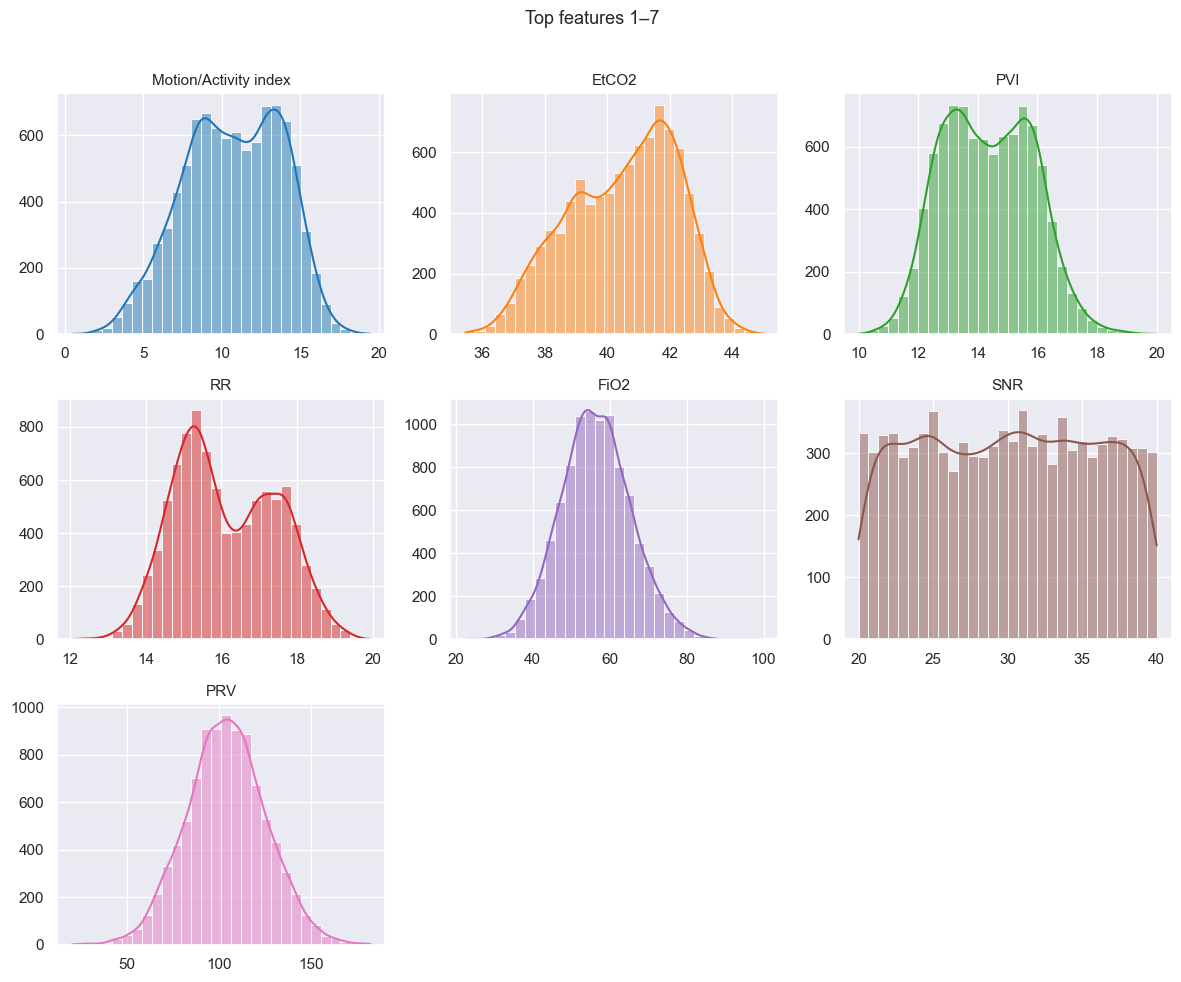

['pickles_ph3/preprocessing_pipeline.pkl']

In [37]:
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')

df_observation.rename(
    columns={
        "SpO₂": "SpO2",
        "EtCO₂": "EtCO2",
        "FiO₂": "FiO2",
        "O₂ extraction ratio": "O2 extraction ratio"
    },
    inplace=True
)

# vieme z fazy 2
selected_features = ["Motion/Activity index", "EtCO2", "PVI", "RR", "FiO2", "SNR", "PRV", "oximetry"]

df = df_observation[selected_features]

df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=['oximetry'])
y = df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

histogramiada(X_train)

pipeline = Pipeline(
    steps=[
        ('quantile_transformer', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('robust_scaler', RobustScaler())
    ]
)

pipeline.fit(X_train)

X_train_processed = pipeline.transform(X_train)
X_test_processed  = pipeline.transform(X_test)

joblib.dump(pipeline, "pickles_ph3/preprocessing_pipeline.pkl")

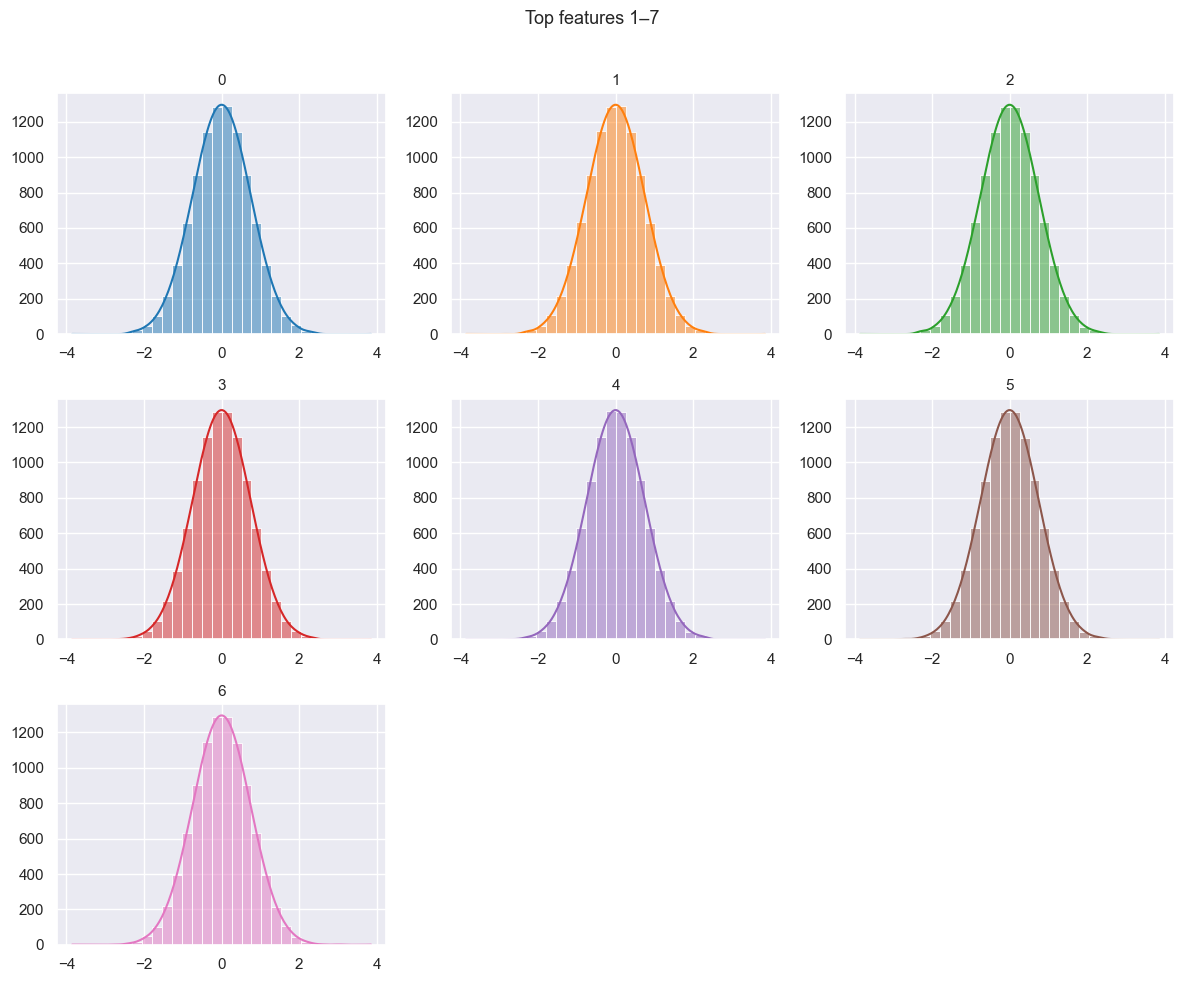

In [38]:
histogramiada(pd.DataFrame(X_train_processed))

# 3.1 Jednoduchý klasifikátor na základe závislosti v dátach

#### 3.1A Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň).

In [39]:
class ID3Classifier:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities))

    def information_gain(self, X_column, y, threshold):
        parent_entropy = self.entropy(y)

        left_mask = X_column <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0

        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        e_left = self.entropy(y[left_mask])
        e_right = self.entropy(y[right_mask])
        child_entropy = (n_left / n) * e_left + (n_right / n) * e_right

        return parent_entropy - child_entropy

    def find_best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                gain = self.information_gain(X_column, y, threshold)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_labels == 1 or \
           n_samples < self.min_samples_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        best_feature, best_threshold, best_gain = self.find_best_split(X, y)

        if best_gain == 0:
            leaf_value = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': leaf_value}

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
        return self

    def predict_sample(self, x, tree):
        if tree['leaf']:
            return tree['value']

        if x[tree['feature']] <= tree['threshold']:
            return self.predict_sample(x, tree['left'])
        else:
            return self.predict_sample(x, tree['right'])

    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)


In [40]:
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

clf = ID3Classifier(max_depth=2)
clf.fit(X_train_np, y_train_np)

y_pred_train = clf.predict(X_train_np)
y_pred_test = clf.predict(X_test_np)

train_accuracy = accuracy_score(y_train_np, y_pred_train)
test_accuracy = accuracy_score(y_test_np, y_pred_test)

accuracy_diff = abs(test_accuracy - train_accuracy)
is_overfitting = accuracy_diff >= 0.1

print("=" * 60)
print("TRAINING SET RESULTS")
print("=" * 60)
print(f"Accuracy: {train_accuracy:.4f}\n")
print(classification_report(y_train_np, y_pred_train))

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test_np, y_pred_test))

print("=" * 60)
print("OVERFITTING EVALUATION")
print("=" * 60)
print(f"Accuracy Difference: {accuracy_diff:.4f}")
print(f"Overfitting Threshold: 0.1000")

if is_overfitting:
    print("[!] Model is OVERFITTING!")
else:
    print("[+] Model is NOT overfitting")

TRAINING SET RESULTS
Accuracy: 0.8074

              precision    recall  f1-score   support

         0.0       0.70      0.93      0.80      3851
         1.0       0.94      0.73      0.82      5644

    accuracy                           0.81      9495
   macro avg       0.82      0.83      0.81      9495
weighted avg       0.84      0.81      0.81      9495

TEST SET RESULTS
Accuracy: 0.8184

              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80       952
         1.0       0.94      0.75      0.83      1422

    accuracy                           0.82      2374
   macro avg       0.82      0.84      0.82      2374
weighted avg       0.85      0.82      0.82      2374

OVERFITTING EVALUATION
Accuracy Difference: 0.0111
Overfitting Threshold: 0.1000
[+] Model is NOT overfitting
